In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as mpl
import numpy as np
import time, os, json

mpl.rcParams['figure.figsize'] = (14, 5)
mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False


In [ ]:
# Guys, use this notebook to make the graphs youll put in your article. Follow the article-template.html file under articles. 
# For the graphs to work, you're going to: 
#1. Turn your graphs into a json. You do this by running the export_for_web() function, specifying it the path of: 
# /articles/data/article-n/your_title.json
#2 Then go into your html, and edit the data-src class with your path. Also, if the chart is an aggregate of many 
# languages, use the aggregate tag in data-chart, if not, use the separate tag. If there is
#another kind of chart you need made, tell me and I'll add it for u



CACHE_DIR = 'data'
os.makedirs(CACHE_DIR, exist_ok=True)

LANGUAGES = {
    'English': 'en', 'French': 'fr', 'German': 'de',
    'Italian': 'it', 'Russian': 'ru', 'Spanish': 'es',
}
LANG_COLORS = {
    'English': '#1f77b4', 'French': '#d62728', 'German': '#2ca02c',
    'Italian': '#ff7f0e', 'Russian': '#9467bd', 'Spanish': '#8c564b',
}

def fetch_ngram(query, corpus='en', start_year=1800, end_year=2019, smoothing=3):
    safe = query.replace(' ', '_').replace('/', '-')[:60]
    cache_path = os.path.join(CACHE_DIR, f'{safe}_{corpus}_{start_year}_{end_year}.json')
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            raw = json.load(f)
    else:
        r = requests.get(
            'https://books.google.com/ngrams/json',
            params={'content': query, 'year_start': start_year,
                    'year_end': end_year, 'corpus': corpus, 'smoothing': smoothing},
            timeout=15
        )
        r.raise_for_status()
        raw = r.json()
        with open(cache_path, 'w') as f:
            json.dump(raw, f)
        time.sleep(0.5)
    if not raw:
        return pd.DataFrame({'year': range(start_year, end_year + 1)})
    years = list(range(start_year, end_year + 1))
    df = pd.DataFrame({'year': years})
    for item in raw:
        df[item['ngram']] = item['timeseries']
    return df

def fetch_across_languages(title_per_lang, start_year=1800, end_year=2019):
    results = {}
    for lang, term in title_per_lang.items():
        df = fetch_ngram(term, corpus=LANGUAGES[lang], start_year=start_year, end_year=end_year)
        col = [c for c in df.columns if c != 'year']
        s = df.set_index('year')[col[0]] if col else pd.Series(0.0, index=range(start_year, end_year + 1))
        s.index.name = 'year'
        results[lang] = s
    return results

def aggregate_across_languages(lang_series):
    parts = [s / s.max() for s in lang_series.values() if s.max() > 0]
    return sum(parts) if parts else None

def add_events(ax, events):
    if not events:
        return
    ymax = ax.get_ylim()[1]
    for year, label in events.items():
        ax.axvline(year, color='grey', linestyle=':', linewidth=1)
        ax.text(year + 0.5, ymax * 0.95, label, fontsize=7, color='grey', rotation=90, va='top')

def export_for_web(series_dict, events, save_path):
    years = list(next(iter(series_dict.values())).index.astype(int))
    payload = {
        'years': years,
        'series': {label: s.values.tolist() for label, s in series_dict.items()},
        'events': {str(k): v for k, v in (events or {}).items()},
    }
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, 'w') as f:
        json.dump(payload, f)

def plot_languages(lang_series, title, publication_year=None, events=None, save_path=None):
    fig, axes = mpl.subplots(1, 2, figsize=(16, 5))
    ax = axes[0]
    for lang, s in lang_series.items():
        ax.plot(s.index, s.values * 1e6, color=LANG_COLORS[lang], label=lang, linewidth=1.5)
    if publication_year:
        ax.axvline(publication_year, color='black', linestyle='--', linewidth=1,
                   label=f'Published ({publication_year})')
    ax.set_title(f'{title}\nFrequency per language (per million words)')
    ax.set_xlabel('Year'); ax.set_ylabel('Freq. per million words'); ax.legend(fontsize=8)
    add_events(ax, events)
    ax2 = axes[1]
    agg = aggregate_across_languages(lang_series)
    if agg is not None:
        ax2.fill_between(agg.index, agg.values, alpha=0.25, color='steelblue')
        ax2.plot(agg.index, agg.values, color='steelblue', linewidth=2)
    if publication_year:
        ax2.axvline(publication_year, color='black', linestyle='--', linewidth=1)
    ax2.set_title(f'{title}\nAggregated cross-language popularity index')
    ax2.set_xlabel('Year'); ax2.set_ylabel('Normalized aggregate')
    add_events(ax2, events)
    mpl.tight_layout()
    if save_path:
        mpl.savefig(save_path, dpi=150, bbox_inches='tight')
    mpl.show()

def plot_separate(lang_series, title, publication_year=None, events=None):
    fig, ax = mpl.subplots(figsize=(14, 5))
    for lang, s in lang_series.items():
        ax.plot(s.index, s.values * 1e6, color=LANG_COLORS[lang], label=lang, linewidth=1.5)
    if publication_year:
        ax.axvline(publication_year, color='black', linestyle='--', linewidth=1,
                   label=f'Published ({publication_year})')
    ax.set_title(f'{title}\nFrequency per language (per million words)')
    ax.set_xlabel('Year'); ax.set_ylabel('Freq. per million words'); ax.legend(fontsize=8)
    add_events(ax, events)
    mpl.tight_layout()
    mpl.show()

def plot_aggregate(lang_series, title, publication_year=None, events=None):
    fig, ax = mpl.subplots(figsize=(14, 5))
    agg = aggregate_across_languages(lang_series)
    if agg is not None:
        ax.fill_between(agg.index, agg.values, alpha=0.25, color='steelblue')
        ax.plot(agg.index, agg.values, color='steelblue', linewidth=2)
    if publication_year:
        ax.axvline(publication_year, color='black', linestyle='--', linewidth=1,
                   label=f'Published ({publication_year})')
    ax.set_title(f'{title}\nAggregated cross-language popularity index')
    ax.set_xlabel('Year'); ax.set_ylabel('Normalized aggregate')
    add_events(ax, events)
    mpl.tight_layout()
    mpl.show()

def plot_comparison(series_dict, title, events=None, save_path=None):
    fig, ax = mpl.subplots(figsize=(14, 5))
    colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']
    for i, (label, s) in enumerate(series_dict.items()):
        ax.plot(s.index, s.values * 1e6, label=label, color=colors[i % len(colors)], linewidth=1.8)
    ax.set_title(title); ax.set_xlabel('Year')
    ax.set_ylabel('Freq. per million words'); ax.legend(fontsize=8)
    add_events(ax, events)
    mpl.tight_layout()
    if save_path:
        mpl.savefig(save_path, dpi=150, bbox_inches='tight')
        json_path = os.path.splitext(save_path)[0] + '.json'
        export_for_web(series_dict, events, json_path)
    mpl.show()

def fetch_series(query, corpus='en', start_year=1800, end_year=2019):
    """Fetch a single ngram as a year-indexed Series. Returns zeros if no data."""
    df = fetch_ngram(query, corpus=corpus, start_year=start_year, end_year=end_year)
    col = [c for c in df.columns if c != 'year']
    if col:
        return df.set_index('year')[col[0]]
    s = pd.Series(0.0, index=pd.Index(range(start_year, end_year + 1), name='year'))
    print(f'  WARNING: no data for "{query}" in corpus={corpus}')
    return s

print('Setup complete.')



Setup complete.


In [5]:
dq_titles = {
    'English': 'Don Quixote',
    'French':  'Don Quichotte',
    'German':  'Don Quijote',
    'Italian': 'Don Chisciotte',
    'Russian': 'Don Quixote',
    'Spanish': 'Don Quixote',
    'Spanish': 'Don Quijote',
}
dq_events = {
    1605: 'Part I published',
    1615: 'Part II published',
    1616: 'Cervantes dies\n(same day as Shakespeare)',
    1620: 'First English\ntranslation (Shelton)',
    1755: 'Smollett English\ntranslation',
    1808: 'Napoleonic invasion\nof Spain',
    1863: 'Dore illustrations\n(cultural revival)',
    1898: 'Spanish-American War\n/ Generation of 98',
    1914: 'WWI begins',
    1936: 'Spanish Civil War\nbegins',
    1939: 'Spanish Civil War ends\n/ Franco dictatorship',
    1965: 'Man of La Mancha\nmusical premieres',
    1975: 'Franco dies\n/ Spanish democracy',
    2005: '400th anniversary\nPart I',
    2015: '400th anniversary\nPart II',
}
dq_lang_data = fetch_across_languages(dq_titles, start_year=1600)
print('Fetched DQ data across', len(dq_lang_data), 'languages')


Fetched DQ data across 6 languages


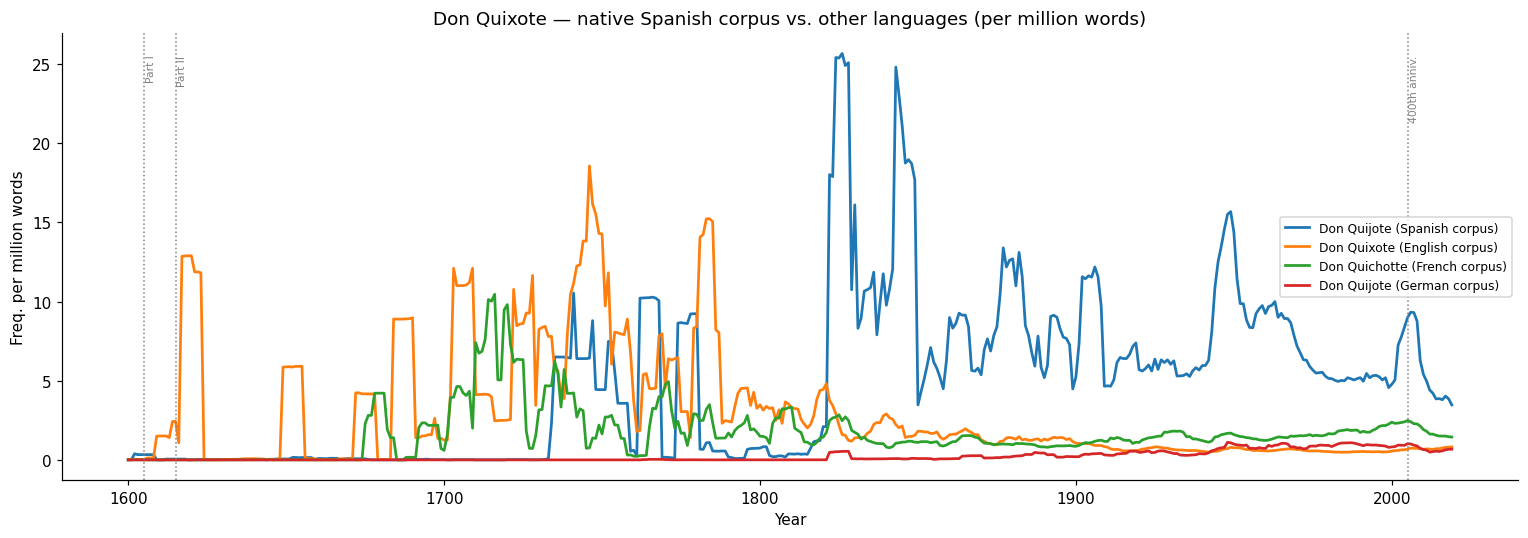

In [14]:
# Don Quixote in its native Spanish corpus vs. other languages
dq_native = {
    'Don Quijote (Spanish corpus)':  fetch_series('Don Quijote',   corpus='es', start_year=1600),
    'Don Quixote (English corpus)':  fetch_series('Don Quixote',   corpus='en', start_year=1600),
    'Don Quichotte (French corpus)': fetch_series('Don Quichotte', corpus='fr', start_year=1600),
    'Don Quijote (German corpus)':   fetch_series('Don Quijote',   corpus='de', start_year=1600),
}
plot_comparison(dq_native, 'Don Quixote — native Spanish corpus vs. other languages (per million words)',
                events={1605: 'Part I', 1615: 'Part II', 2005: '400th anniv.'},
                save_path='figures/don_quixote/native_language_comparison.png')

In [9]:
six_and_five_comparison = {
    "The Great Gatsby":                     fetch_series('The Great Gatsby'),
    "Brave New World":                  fetch_series('Brave New World'),
    "Jane Eyre":                            fetch_series('Jane Eyre'),
    "Little Women":                     fetch_series('Little Women'),
    "Moby Dick":                        fetch_series('Moby Dick'),
    "Nineteen Eighty-Four":             fetch_series('Nineteen Eighty-Four'),
    "Pride and Prejudice":                  fetch_series('Pride and Prejudice'),
    "To Kill a Mockingbird":                fetch_series('To Kill a Mockingbird'),
    "Don Quixote":    fetch_series("Don Quixote")
}


publication_dates = {
    1813: 'Pride and Prejudice (Austen 1813)',
    1925: "The Great Gatsby",
    1932: "Brave New World",
    1847: "Jane Eyre",
    1868: "Little women",
    1851: "Moby dick",
    1949: "Nineteen eighty-four",
    1813: "Pride and prejudice",
    1951: "The catcher in the rye",
    1960: "To kill a mockingbird",
}

export_for_web(six_and_five_comparison, publication_dates, './articles/data/article-1/don-quijote-comparison.json')